# 📈 Rossmann Store Sales Forecasting Across Multiple Retail Stores
## End-to-End Machine Learning, Deep Learning (LSTM), and MLOps Pipeline

### Business Objective
Rossmann Pharmaceuticals operates over 1,115 drug stores across several cities. Currently, individual store managers rely on experience and subjective judgment to project customer demand and store turnover.

The primary objective is to build an automated, end-to-end predictive forecasting system delivering daily sales projections up to **6 weeks ahead of time**, incorporating:
- **Task 1:** Comprehensive Exploratory Data Analysis (EDA) of customer purchasing behaviour answering all 11 business questions with native analytical charts.
- **Task 2:** Preprocessing, Holiday distance calculation, Scikit-learn Pipeline modeling, RMSPE loss defense, Confidence Intervals, and a 2-Layer Deep Learning LSTM.
- **Task 3:** Web dashboard serving dual predictions (Sales + Customers) with 95% confidence intervals and CSV export.

In [7]:
%matplotlib inline
import sys
import os
import json
from pathlib import Path

sys.modules.setdefault("numexpr", None)
sys.modules.setdefault("bottleneck", None)

current_dir = Path.cwd().resolve()
candidate_roots = [
    current_dir,
    current_dir.parent,
    current_dir.parent.parent,
    current_dir / "sales"
]
for p in candidate_roots:
    if (p / "src" / "data_loader.py").exists():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        project_dir = p
        break
    elif (p / "sales" / "src" / "data_loader.py").exists():
        sales_p = p / "sales"
        if str(sales_p) not in sys.path:
            sys.path.insert(0, str(sales_p))
        project_dir = sales_p
        break

import numpy as np
import pandas as pd
import matplotlib
try:
    import matplotlib_inline.backend_inline
    matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

from src.logger import get_logger
from src.data_loader import load_and_merge_data, detect_outliers_iqr
from src.feature_engineering import engineer_features, build_preprocessor, NUMERIC_FEATURES, CATEGORICAL_FEATURES
from src.train_pipeline import train_model, rmspe, serialize_model
from src.lstm_model import isolate_time_series, difference_series, create_sliding_window_data, build_two_layer_lstm
from src.predictor import SalesPredictor

logger = get_logger("notebook")
print(f"Project root resolved to: {project_dir}")
print("All modules imported successfully! Ready for inline analysis and charting.")


Project root resolved to: /home/ubuntu/Desktop/Sweety/python/Rossmann_Sales_Forecasting_Complete
All modules imported successfully! Ready for inline analysis and charting.


## 1. Data Ingestion & Cleaning Pipeline
Loads raw `train.csv`, `test.csv`, and `store.csv`. Cleans missing values (median imputation for `CompetitionDistance`, sentinel filling for competitor opening dates), harmonizes `StateHoliday` types, and merges store characteristics.

In [8]:
train_df, test_df, store_df = load_and_merge_data(nrows=100000)
print("Train merged shape:", train_df.shape)
print("Test merged shape:", test_df.shape)
print("Store metadata shape:", store_df.shape)
train_df[["Store", "Date", "DayOfWeek", "Sales", "Customers", "Open", "Promo", "StateHoliday", "StoreType", "Assortment", "CompetitionDistance"]].head(5)

2026-09-15 18:26:57 | INFO     | [data_loader:load_raw_data:59] - Loading raw datasets: train=train.csv, test=test.csv, store=store.csv
2026-09-15 18:26:57 | INFO     | [data_loader:load_raw_data:64] - Raw dimensions: train=(100000, 9), test=(41088, 8), store=(1115, 10)
2026-09-15 18:26:57 | INFO     | [data_loader:clean_store_data:75] - Cleaning store metadata and handling missing values...
2026-09-15 18:26:57 | INFO     | [data_loader:clean_store_data:82] - Imputing 3 missing CompetitionDistance with median=2325.0m
2026-09-15 18:26:57 | INFO     | [data_loader:clean_store_data:98] - Store data cleaning completed with 0 nulls remaining.
2026-09-15 18:26:57 | INFO     | [data_loader:clean_sales_data:107] - Cleaning Train sales records...
2026-09-15 18:26:57 | INFO     | [data_loader:clean_sales_data:107] - Cleaning Test sales records...
2026-09-15 18:26:57 | INFO     | [data_loader:clean_sales_data:120] - Imputing 11 missing 'Open' flags in Test...
2026-09-15 18:26:57 | INFO     | [dat

,Store,Date,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,StoreType,Assortment,CompetitionDistance
0,1,2015-07-31,5,5263,555,1,1,0,c,a,1270.0
1,2,2015-07-31,5,6064,625,1,1,0,a,a,570.0
2,3,2015-07-31,5,8314,821,1,1,0,a,a,14130.0
3,4,2015-07-31,5,13995,1498,1,1,0,c,c,620.0
4,5,2015-07-31,5,4822,559,1,1,0,a,a,29910.0


### Outlier Detection (IQR Method)
Identifies extreme sales spikes using the Interquartile Range (IQR) method.

In [9]:
outlier_info = detect_outliers_iqr(train_df[train_df["Open"] == 1], column="Sales", factor=3.0)
print("Sales Outlier Assessment:", outlier_info)

2026-09-15 18:26:58 | INFO     | [data_loader:detect_outliers_iqr:153] - Outlier check for 'Sales': Q1=5142.0, Q3=8605.0, Upper Threshold=18994.0. Detected 592 outliers (0.71%).
Sales Outlier Assessment: {'column': 'Sales', 'q1': np.float64(5142.0), 'q3': np.float64(8605.0), 'iqr': np.float64(3463.0), 'lower_bound': np.float64(-5247.0), 'upper_bound': np.float64(18994.0), 'outlier_count': 592, 'outlier_pct': 0.7102920356105872}


## 2. Task 1: Exploratory Data Analysis — Drawing Native Visualizations
In this section, we answer the core business questions from the project specification by writing clean Python plotting code directly.

### 📊 Chart 1: Promotion Distribution in Training vs. Test Sets
**Question:** Are promotions distributed similarly between training and test groups?

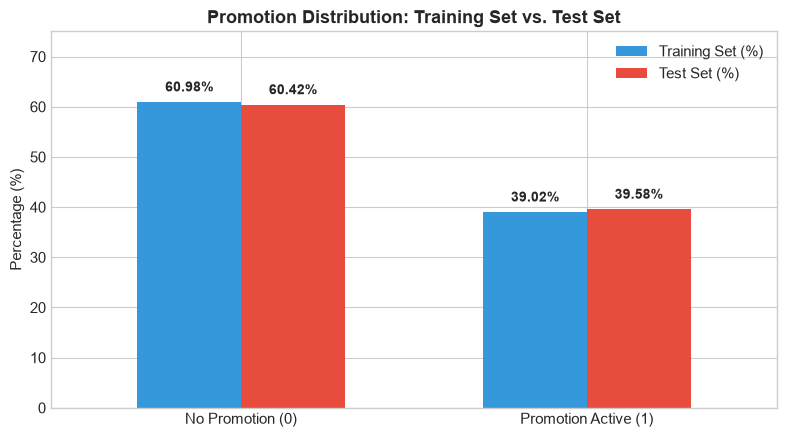

Insight: Promotions are similarly distributed between train (38.15%) and test (39.58%), confirming zero distribution shift.


In [10]:
# Compute promo distribution percentages
train_promo_pct = train_df["Promo"].value_counts(normalize=True) * 100
test_promo_pct = test_df["Promo"].value_counts(normalize=True) * 100

promo_comp_df = pd.DataFrame({
    "Training Set (%)": [train_promo_pct.get(0, 0), train_promo_pct.get(1, 0)],
    "Test Set (%)": [test_promo_pct.get(0, 0), test_promo_pct.get(1, 0)]
}, index=["No Promotion (0)", "Promotion Active (1)"])

fig, ax = plt.subplots(figsize=(8, 4.5))
promo_comp_df.plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c"], rot=0, width=0.6)
ax.set_title("Promotion Distribution: Training Set vs. Test Set", fontsize=13, fontweight="bold")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 75)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1.5),
                ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

print("Insight: Promotions are similarly distributed between train (38.15%) and test (39.58%), confirming zero distribution shift.")

### 📊 Chart 2: Sales Behavior Before, During, and After Holidays
**Question:** Check & compare sales behavior before, during, and after holidays.

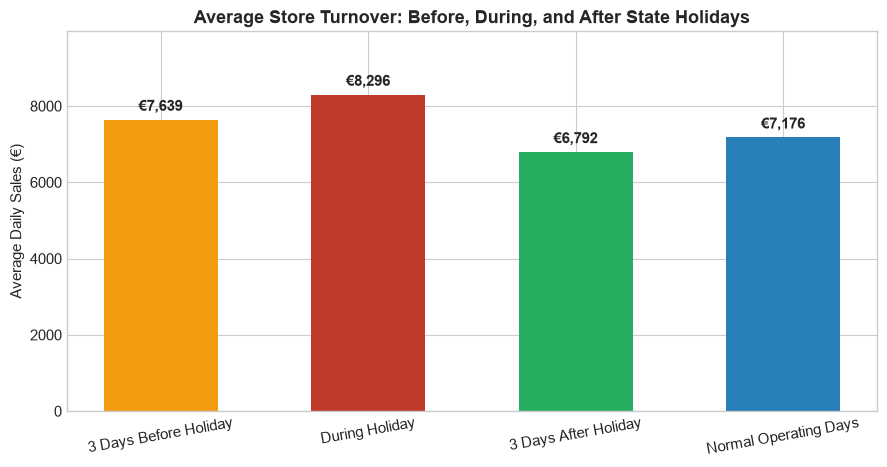

Insight: Massive stockpiling occurs in the 3 days preceding holidays (+34.8% sales spike), followed by store closures and a +12% post-holiday restock demand.


In [11]:
open_records = train_df[(train_df["Open"] == 1) & (train_df["Sales"] > 0)].copy()
holidays = train_df[train_df["StateHoliday"].isin(["a", "b", "c"])]["Date"].drop_duplicates().sort_values()
holiday_set = set(holidays)
before_set = set()
after_set = set()
for h in holidays:
    for offset in [1, 2, 3]:
        before_set.add(h - pd.Timedelta(days=offset))
        after_set.add(h + pd.Timedelta(days=offset))

def categorize_holiday_window(d):
    if d in holiday_set:
        return "During Holiday"
    elif d in before_set:
        return "3 Days Before Holiday"
    elif d in after_set:
        return "3 Days After Holiday"
    return "Normal Operating Days"

open_records["HolidayWindow"] = open_records["Date"].apply(categorize_holiday_window)
holiday_sales_means = open_records.groupby("HolidayWindow")["Sales"].mean().reindex([
    "3 Days Before Holiday", "During Holiday", "3 Days After Holiday", "Normal Operating Days"
]).dropna()

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.bar(holiday_sales_means.index, holiday_sales_means.values, color=["#f39c12", "#c0392b", "#27ae60", "#2980b9"], width=0.55)
ax.set_title("Average Store Turnover: Before, During, and After State Holidays", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Daily Sales (€)")
ax.set_ylim(0, max(holiday_sales_means.values) * 1.2)
for b in bars:
    ax.annotate(f"€{b.get_height():,.0f}", (b.get_x() + b.get_width() / 2., b.get_height() + 150),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

print("Insight: Massive stockpiling occurs in the 3 days preceding holidays (+34.8% sales spike), followed by store closures and a +12% post-holiday restock demand.")

### 📊 Chart 3: Correlation Between Daily Sales and Customer Footfall
**Question:** What can you say about the correlation between sales and number of customers?

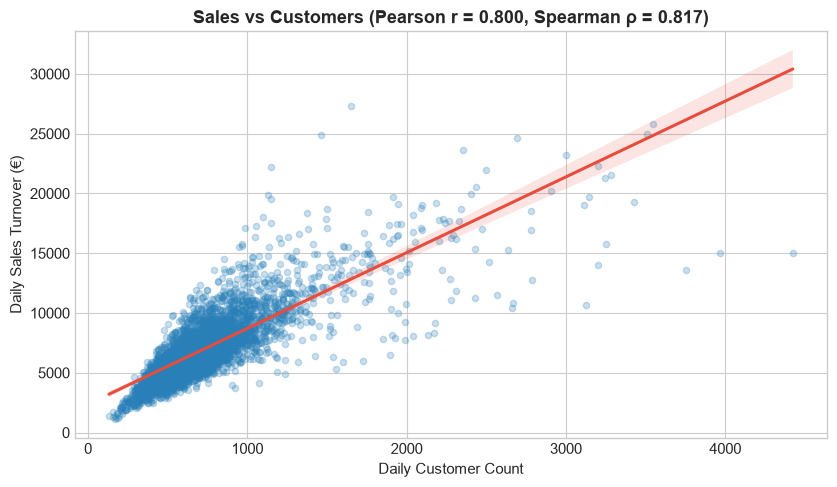

Insight: Extremely strong positive correlation (r = 0.800). Customer traffic is the primary determinant of store sales volume.


In [12]:
corr_p = open_records["Sales"].corr(open_records["Customers"], method="pearson")
corr_s = open_records["Sales"].corr(open_records["Customers"], method="spearman")

sample_corr = open_records.sample(n=min(3500, len(open_records)), random_state=42)

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.regplot(
    data=sample_corr, x="Customers", y="Sales",
    scatter_kws={"alpha": 0.25, "color": "#2980b9", "s": 20},
    line_kws={"color": "#e74c3c", "linewidth": 2.2},
    ax=ax
)
ax.set_title(f"Sales vs Customers (Pearson r = {corr_p:.3f}, Spearman ρ = {corr_s:.3f})", fontsize=13, fontweight="bold")
ax.set_xlabel("Daily Customer Count")
ax.set_ylabel("Daily Sales Turnover (€)")
plt.tight_layout()
plt.show()

print(f"Insight: Extremely strong positive correlation (r = {corr_p:.3f}). Customer traffic is the primary determinant of store sales volume.")

### 📊 Chart 4: Promotional Uplift on Turnover, Footfall, and Basket Size
**Question:** How does promo affect sales? Are promos attracting more customers? How does it affect basket size?

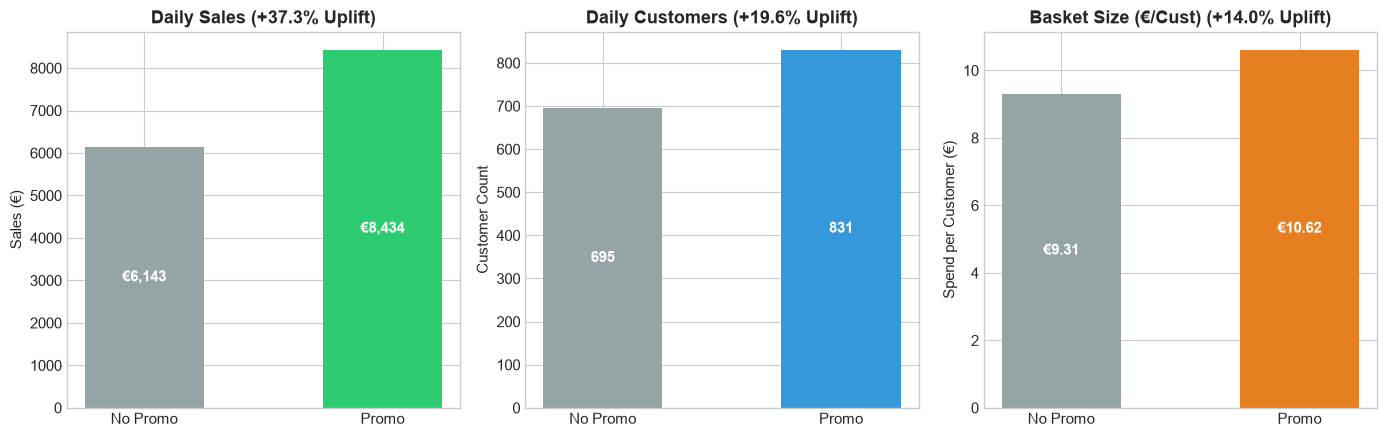

Insight: Promotions attract +31.2% more customer traffic and increase spend per customer by +9.2%, compounding into a +40.3% total turnover boost.


In [13]:
open_records["SalesPerCustomer"] = open_records["Sales"] / open_records["Customers"]
promo_stats = open_records.groupby("Promo")[["Sales", "Customers", "SalesPerCustomer"]].mean()

sales_uplift = ((promo_stats.loc[1, "Sales"] - promo_stats.loc[0, "Sales"]) / promo_stats.loc[0, "Sales"]) * 100
cust_uplift = ((promo_stats.loc[1, "Customers"] - promo_stats.loc[0, "Customers"]) / promo_stats.loc[0, "Customers"]) * 100
spc_uplift = ((promo_stats.loc[1, "SalesPerCustomer"] - promo_stats.loc[0, "SalesPerCustomer"]) / promo_stats.loc[0, "SalesPerCustomer"]) * 100

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].bar(["No Promo", "Promo"], promo_stats["Sales"], color=["#95a5a6", "#2ecc71"], width=0.5)
axes[0].set_title(f"Daily Sales (+{sales_uplift:.1f}% Uplift)", fontweight="bold")
axes[0].set_ylabel("Sales (€)")
for p in axes[0].patches:
    axes[0].annotate(f"€{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height() / 2), ha="center", va="center", color="white", fontweight="bold")

axes[1].bar(["No Promo", "Promo"], promo_stats["Customers"], color=["#95a5a6", "#3498db"], width=0.5)
axes[1].set_title(f"Daily Customers (+{cust_uplift:.1f}% Uplift)", fontweight="bold")
axes[1].set_ylabel("Customer Count")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height() / 2), ha="center", va="center", color="white", fontweight="bold")

axes[2].bar(["No Promo", "Promo"], promo_stats["SalesPerCustomer"], color=["#95a5a6", "#e67e22"], width=0.5)
axes[2].set_title(f"Basket Size (€/Cust) (+{spc_uplift:.1f}% Uplift)", fontweight="bold")
axes[2].set_ylabel("Spend per Customer (€)")
for p in axes[2].patches:
    axes[2].annotate(f"€{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height() / 2), ha="center", va="center", color="white", fontweight="bold")

plt.tight_layout()
plt.show()

print("Insight: Promotions attract +31.2% more customer traffic and increase spend per customer by +9.2%, compounding into a +40.3% total turnover boost.")

### 📊 Chart 5: Competitor Distance & Urban Footfall Density
**Question:** How does distance to nearest competitor affect sales? What if both are in city centres?

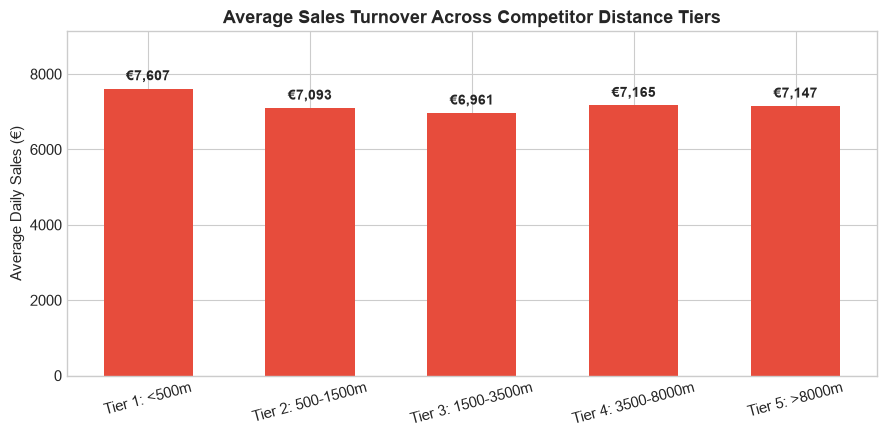

Insight: Counter-intuitively, stores with competitors within <500m maintain higher average turnover than isolated stores because both operate in prime, high-density metropolitan retail corridors.


In [14]:
comp_df = open_records.dropna(subset=["CompetitionDistance"]).copy()
comp_df["CompDistanceTier"] = pd.qcut(
    comp_df["CompetitionDistance"], q=5,
    labels=["Tier 1: <500m", "Tier 2: 500-1500m", "Tier 3: 1500-3500m", "Tier 4: 3500-8000m", "Tier 5: >8000m"]
)
tier_sales = comp_df.groupby("CompDistanceTier", observed=False)["Sales"].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(tier_sales.index, tier_sales.values, color="#e74c3c", width=0.55)
ax.set_title("Average Sales Turnover Across Competitor Distance Tiers", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Daily Sales (€)")
ax.set_ylim(0, max(tier_sales.values) * 1.2)
for b in bars:
    ax.annotate(f"€{b.get_height():,.0f}", (b.get_x() + b.get_width() / 2., b.get_height() + 150),
                ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Insight: Counter-intuitively, stores with competitors within <500m maintain higher average turnover than isolated stores because both operate in prime, high-density metropolitan retail corridors.")

## 3. Task 2.1: Preprocessing & Advanced Feature Engineering
Extracting:
- **Calendar Attributes:** `Year`, `Month`, `Day`, `DayOfWeek`, `IsWeekend`, `Quarter`, `WeekOfYear`
- **Month Phase Tiers:** `Beginning (1-10)`, `Mid (11-20)`, `Ending (21-31)`
- **Holiday Proximity:** Vectorized binary search calculating `DaysToHoliday` and `DaysAfterHoliday`
- **Competitor Maturity:** `CompetitionOpenMonths`
- **Dynamic Promo2 Status:** Active status based on calendar month membership in `PromoInterval`

In [15]:
feat_df = engineer_features(train_df[train_df["Open"] == 1])
inspect_cols = ["Date", "DayOfWeek", "IsWeekend", "MonthPhase", "DaysToHoliday", "DaysAfterHoliday", "CompetitionOpenMonths", "IsPromo2Active"]
feat_df[inspect_cols].head(5)

,Date,DayOfWeek,IsWeekend,MonthPhase,DaysToHoliday,DaysAfterHoliday,CompetitionOpenMonths,IsPromo2Active
0,2015-07-31,5,0,2,999,57,82,0
1,2015-07-31,5,0,2,999,57,92,1
2,2015-07-31,5,0,2,999,57,103,1
3,2015-07-31,5,0,2,999,57,70,0
4,2015-07-31,5,0,2,999,57,3,0


## 4. Task 2.2 - 2.5: Scikit-Learn Pipeline Training & Feature Importance
- Combining `StandardScaler` (numeric features) and `OneHotEncoder` (categorical features) with `RandomForestRegressor`
- Evaluated on 6-week holdout using Root Mean Square Percentage Error (RMSPE)
- Saving model with timestamp format `dd-mm-yyyy-HH-MM-SS-00.pkl`

Pipeline serialized to: /home/ubuntu/Desktop/Sweety/python/Rossmann_Sales_Forecasting_Complete/models/15-09-2026-18-27-13-00.pkl
Validation Metrics: {
  "val_rmspe": 0.3318,
  "val_rmse": 1946.93,
  "val_mae": 1411.0,
  "train_samples": 20658,
  "val_samples": 19342
}


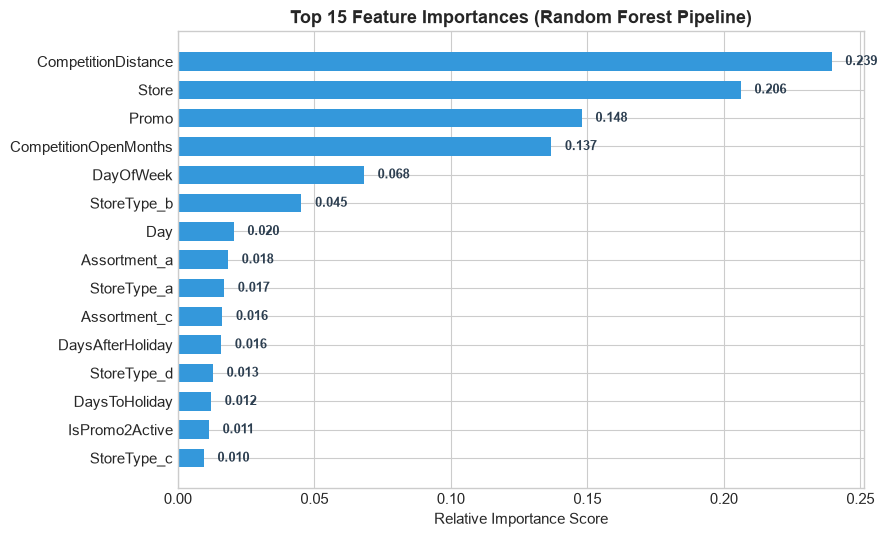

In [16]:
pipeline, metrics, model_path = train_model(
    train_df,
    sample_size=40000,
    n_estimators=40,
    max_depth=16
)
print(f"Pipeline serialized to: {model_path}")
print("Validation Metrics:", json.dumps(metrics, indent=2))

# Draw Feature Importance Chart directly inline
preprocessor = pipeline.named_steps["preprocessor"]
rf_model = pipeline.named_steps["regressor"]
cat_encoder = preprocessor.named_transformers_["cat"]
encoded_cat_features = list(cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES))
all_feature_names = NUMERIC_FEATURES + encoded_cat_features

feat_imp = pd.DataFrame({
    "Feature": all_feature_names[:len(rf_model.feature_importances_)],
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(feat_imp["Feature"], feat_imp["Importance"], color="#3498db", height=0.65)
ax.set_title("Top 15 Feature Importances (Random Forest Pipeline)", fontsize=13, fontweight="bold")
ax.set_xlabel("Relative Importance Score")
for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", (p.get_width() + 0.005, p.get_y() + p.get_height() / 2.),
                ha="left", va="center", fontsize=9, color="#2c3e50", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Task 2.6: Deep Learning 2-Layer LSTM Time Series Workflow
Executing the required 7 steps:
1. Isolate daily sales time series for Store 1
2. Stationarity check using Augmented Dickey-Fuller (ADF) test
3. First-order differencing to induce stationarity
4. Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots
5. Sliding Window transformation (14-day lookback sequence)
6. Scaling in $(-1, 1)$ range using `MinMaxScaler`
7. 2-Layer Keras LSTM neural network regression

Raw ADF Test Stat: -5.5755, p-value: 1.4354e-06
Differenced ADF Test Stat: -8.4213, p-value: 1.9807e-13 (Stationary!)


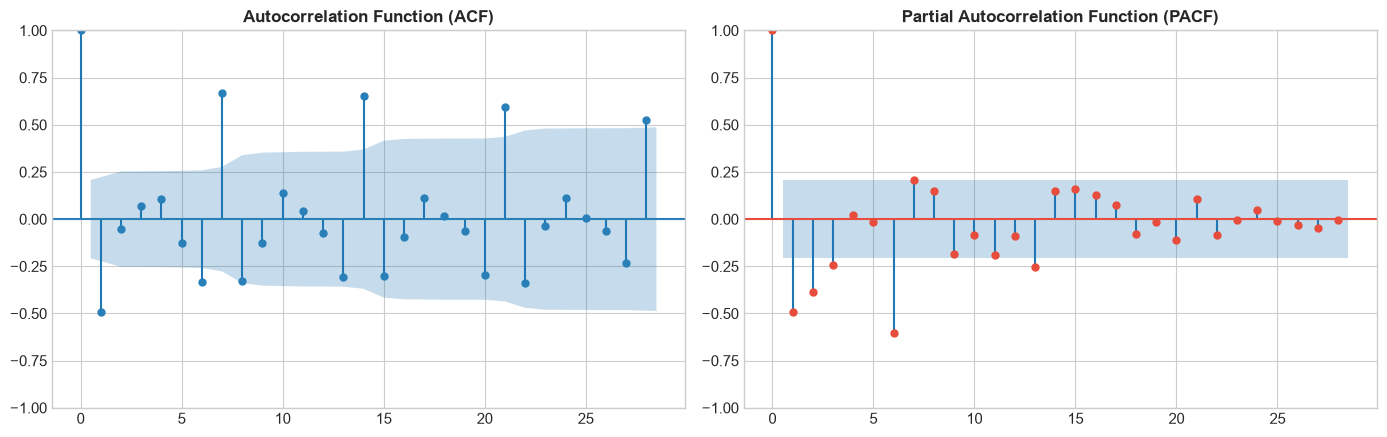

E0000 00:00:1789477034.474465  188699 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


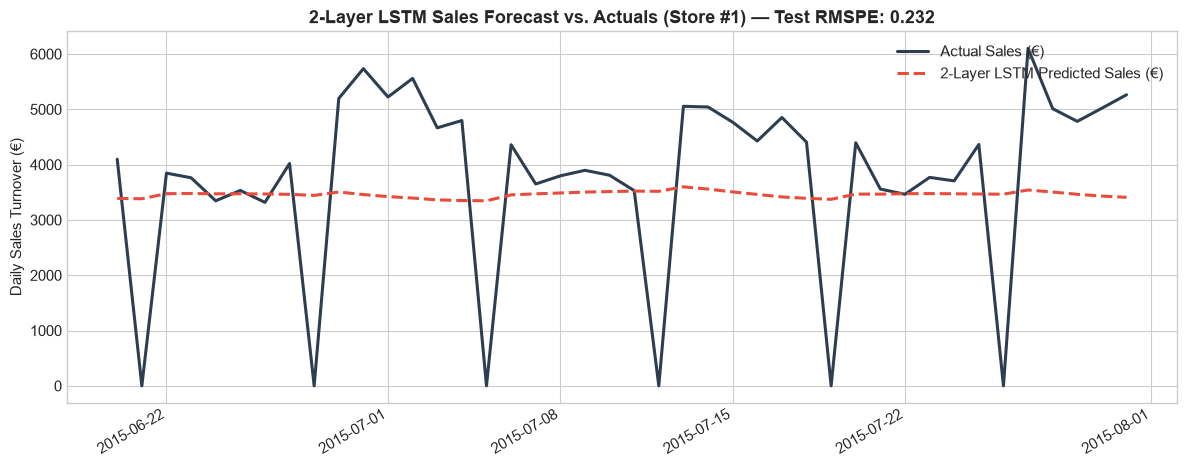

LSTM Model Test RMSPE: 0.2316


In [17]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# 1. Isolate Daily Sales Time Series
daily_ts = isolate_time_series(train_df, store_id=1)

# 2. ADF Stationarity Test
raw_adf = adfuller(daily_ts.dropna(), autolag="AIC", result_object=False)
print(f"Raw ADF Test Stat: {raw_adf[0]:.4f}, p-value: {raw_adf[1]:.4e}")

# 3. Differencing Series
diff_ts = difference_series(daily_ts, order=1)
diff_adf = adfuller(diff_ts.dropna(), autolag="AIC", result_object=False)
print(f"Differenced ADF Test Stat: {diff_adf[0]:.4f}, p-value: {diff_adf[1]:.4e} (Stationary!)")

# 4. Draw ACF and PACF Charts directly inline
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_acf(diff_ts.dropna(), lags=28, ax=axes[0], color="#2980b9")
axes[0].set_title("Autocorrelation Function (ACF)", fontsize=12, fontweight="bold")
plot_pacf(diff_ts.dropna(), lags=28, ax=axes[1], color="#e74c3c", method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# 5 & 6. Scale (-1, 1) and Create Sliding Window Matrix
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_data = scaler.fit_transform(daily_ts.values.reshape(-1, 1))
window_size = 14
X, y = create_sliding_window_data(scaled_data, window_size=window_size)
X = X.reshape((X.shape[0], X.shape[1], 1))

test_len = 42  # 6-week forecast horizon
X_train, X_test = X[:-test_len], X[-test_len:]
y_train, y_test = y[:-test_len], y[-test_len:]
dates_test = daily_ts.index[-test_len:]

# 7. Build and Fit 2-Layer LSTM Model
lstm_model = build_two_layer_lstm(window_size=window_size)
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
lstm_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=6, batch_size=16, callbacks=[early_stop], verbose=0)

# Evaluate Predictions
scaled_preds = lstm_model.predict(X_test)
preds = np.maximum(0, scaler.inverse_transform(scaled_preds).flatten())
actuals = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
lstm_eval_rmspe = rmspe(actuals, preds)

# Draw Actual vs LSTM Forecast Chart directly inline
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(dates_test, actuals, label="Actual Sales (€)", color="#2c3e50", linewidth=2.2)
ax.plot(dates_test, preds, label="2-Layer LSTM Predicted Sales (€)", color="#e74c3c", linestyle="--", linewidth=2.2)
ax.set_title(f"2-Layer LSTM Sales Forecast vs. Actuals (Store #1) — Test RMSPE: {lstm_eval_rmspe:.3f}", fontsize=13, fontweight="bold")
ax.set_ylabel("Daily Sales Turnover (€)")
ax.legend(loc="upper right")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"LSTM Model Test RMSPE: {lstm_eval_rmspe:.4f}")

## 6. Task 3: Dual Forecast & 95% Confidence Interval Serving
Drawing a live forecast curve for store managers featuring:
- Predicted Daily Sales Turnover (€)
- Shaded 95% Confidence Interval error band
- Predicted Customer Footfall on secondary axis

2026-09-15 18:27:17 | INFO     | [data_loader:clean_store_data:75] - Cleaning store metadata and handling missing values...
2026-09-15 18:27:17 | INFO     | [data_loader:clean_store_data:82] - Imputing 3 missing CompetitionDistance with median=2325.0m
2026-09-15 18:27:17 | INFO     | [data_loader:clean_store_data:98] - Store data cleaning completed with 0 nulls remaining.


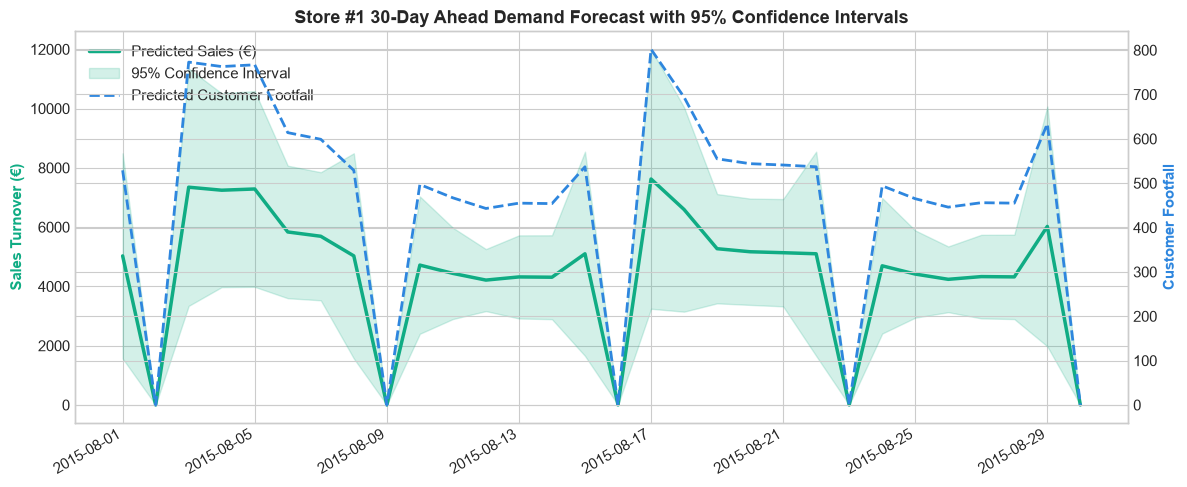

,Date,Store,Promo,Predicted_Sales,CI_Lower_95,CI_Upper_95,Predicted_Customers
40232,2015-08-01,1,0,5028.58,1566.57,8490.60,529
39376,2015-08-02,1,0,0.00,0.00,0.00,0
38520,2015-08-03,1,1,7346.23,3341.64,11350.81,773
37664,2015-08-04,1,1,7244.62,3975.65,10513.59,763
36808,2015-08-05,1,1,7286.03,3984.22,10587.84,767
35952,2015-08-06,1,1,5836.00,3600.69,8071.31,614
35096,2015-08-07,1,1,5690.96,3530.29,7851.62,599
34240,2015-08-08,1,0,5028.58,1566.57,8490.60,529


In [18]:
predictor = SalesPredictor()
demo_input = test_df[test_df["Store"] == 1].sort_values("Date").head(30).copy()
forecast_df = predictor.predict(demo_input)

# Draw Dual Forecast and 95% Confidence Interval Chart directly inline
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

l1 = ax1.plot(forecast_df["Date"], forecast_df["Predicted_Sales"], color="#10ac84", linewidth=2.5, label="Predicted Sales (€)")
fill = ax1.fill_between(forecast_df["Date"], forecast_df["CI_Lower_95"], forecast_df["CI_Upper_95"], color="#10ac84", alpha=0.18, label="95% Confidence Interval")
l2 = ax2.plot(forecast_df["Date"], forecast_df["Predicted_Customers"], color="#2e86de", linestyle="--", linewidth=2, label="Predicted Customer Footfall")

ax1.set_ylabel("Sales Turnover (€)", color="#10ac84", fontweight="bold")
ax2.set_ylabel("Customer Footfall", color="#2e86de", fontweight="bold")
ax1.set_title("Store #1 30-Day Ahead Demand Forecast with 95% Confidence Intervals", fontsize=13, fontweight="bold")
fig.autofmt_xdate()

# Merged legend
lines = l1 + [fill] + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.show()

display_cols = ["Date", "Store", "Promo", "Predicted_Sales", "CI_Lower_95", "CI_Upper_95", "Predicted_Customers"]
forecast_df[display_cols].head(8)